# 🔧 Lab 04: Embedding Finetune 實作

## 學習目標
在本實驗中，您將學習：
1. **Sentence Transformers 訓練流程** - 完整的 finetune pipeline
2. **Loss Functions 比較** - MultipleNegativesRankingLoss vs CosineSimilarityLoss
3. **Training 配置** - Learning rate, batch size, warmup 等參數
4. **評估與比較** - 量化 finetune 前後的效能差異

## 為什麼需要 Finetune？
- 預訓練模型是通用的，可能不適合特定領域
- Finetune 可以讓模型學習領域專屬的語義
- 通常只需要少量資料就能看到顯著改進

## 技術棧
- **Training Framework**: `sentence-transformers`
- **Hardware**: GPU 推薦 (CPU 也可以，但較慢)

---

## 📦 Part 1: 環境設置

In [ ]:
# 安裝必要套件
!pip install --quiet sentence-transformers>=2.2.0
!pip install --quiet torch
!pip install --quiet pandas numpy matplotlib
!pip install --quiet scikit-learn
!pip install --quiet rank_bm25

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Set, Tuple

import torch
from torch.utils.data import DataLoader

from sentence_transformers import (
    SentenceTransformer,
    InputExample,
    losses,
    evaluation,
)
from sentence_transformers.evaluation import (
    InformationRetrievalEvaluator,
    EmbeddingSimilarityEvaluator,
)
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

# 檢查 GPU
device = 'cuda'
print(f"✅ 使用裝置: {device}")
if device == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

/home/user/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 使用裝置: cuda
   GPU: NVIDIA GeForce RTX 4070 Ti SUPER
   VRAM: 16.7 GB


---
## 📊 Part 2: 準備訓練資料

### 建立 FAQ 資料集

我們將建立一個客服 FAQ 資料集，包含：
- 問題 (Queries)
- 標準答案 (Positives)
- 用於挖掘負樣本的文件庫 (Corpus)

In [2]:
# 建立 FAQ 資料集

faq_data = [
    # (問題, 標準答案)
    ("How do I reset my password?", 
     "To reset your password, go to the login page and click 'Forgot Password'. Enter your email and follow the instructions sent to your inbox."),
    
    ("What are your business hours?", 
     "Our customer service is available Monday to Friday, 9 AM to 6 PM EST. For urgent matters, you can use our 24/7 chatbot."),
    
    ("How can I track my order?", 
     "You can track your order by logging into your account and visiting 'My Orders'. Alternatively, use the tracking number from your confirmation email."),
    
    ("What is your return policy?", 
     "We offer a 30-day return policy for unused items in original packaging. Contact customer support to initiate a return."),
    
    ("How do I cancel my subscription?", 
     "To cancel your subscription, go to Account Settings > Subscription > Cancel. You'll retain access until the end of your billing period."),
    
    ("Do you offer international shipping?", 
     "Yes, we ship to over 100 countries. International shipping rates and delivery times vary by location. Check our shipping page for details."),
    
    ("How can I contact customer support?", 
     "You can reach customer support via email at support@example.com, phone at 1-800-123-4567, or live chat on our website."),
    
    ("What payment methods do you accept?", 
     "We accept Visa, MasterCard, American Express, PayPal, Apple Pay, and Google Pay. All transactions are secured with SSL encryption."),
    
    ("How do I update my billing information?", 
     "Go to Account Settings > Payment Methods. You can add, edit, or remove payment methods. Changes take effect immediately."),
    
    ("Is my personal data secure?", 
     "Yes, we use industry-standard encryption and security protocols. Your data is stored securely and never shared with third parties without consent."),
    
    ("How do I change my email address?", 
     "Go to Account Settings > Personal Information > Email. Enter your new email and verify it by clicking the link sent to your new address."),
    
    ("Can I get a refund?", 
     "Refunds are processed within 5-7 business days after we receive your returned item. The refund will be credited to your original payment method."),
    
    ("How do I apply a discount code?", 
     "Enter your discount code in the 'Promo Code' field at checkout and click 'Apply'. The discount will be reflected in your order total."),
    
    ("What if my package is lost?", 
     "If your package is lost, contact us with your order number. We'll investigate with the carrier and either resend the items or issue a full refund."),
    
    ("How do I create an account?", 
     "Click 'Sign Up' on our homepage. Enter your email, create a password, and complete the registration form. You'll receive a confirmation email."),
]

# 分割為訓練和測試集
train_data = faq_data[:12]
test_data = faq_data[12:]

print(f"📊 資料集統計:")
print(f"   訓練集: {len(train_data)} 個問答對")
print(f"   測試集: {len(test_data)} 個問答對")

📊 資料集統計:
   訓練集: 12 個問答對
   測試集: 3 個問答對


In [3]:
# 建立文件庫 (用於 hard negative mining 和評估)
corpus = [answer for _, answer in faq_data]

# 加入一些干擾文件
additional_docs = [
    "Our company was founded in 2010 and has grown to serve millions of customers worldwide.",
    "Subscribe to our newsletter to receive exclusive offers and updates about new products.",
    "Our mobile app is available on both iOS and Android platforms for convenient shopping.",
    "We value customer feedback and continuously improve our services based on your suggestions.",
    "Join our loyalty program to earn points on every purchase and unlock special rewards.",
]
corpus.extend(additional_docs)

print(f"📚 文件庫: {len(corpus)} 個文件")

📚 文件庫: 20 個文件


In [4]:
# Hard Negative Mining
from rank_bm25 import BM25Okapi

def mine_hard_negatives(
    query: str,
    positive: str,
    corpus: List[str],
    model: SentenceTransformer,
    top_k: int = 3
) -> List[str]:
    """使用語義相似度挖掘 hard negatives"""
    q_emb = model.encode(query)
    c_embs = model.encode(corpus)
    
    sims = cosine_similarity([q_emb], c_embs)[0]
    sorted_indices = np.argsort(sims)[::-1]
    
    negatives = []
    for idx in sorted_indices:
        if corpus[idx] != positive and len(negatives) < top_k:
            negatives.append(corpus[idx])
    
    return negatives

# 載入基礎模型用於 mining
import os
os.environ["HF_HOME"] = "./hf_cache"
os.makedirs(os.environ["HF_HOME"], exist_ok=True)
base_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    cache_folder="./hf_cache",
)

# 為訓練資料建立完整的三元組
training_triplets = []
for query, positive in train_data:
    negatives = mine_hard_negatives(query, positive, corpus, base_model, top_k=2)
    for negative in negatives:
        training_triplets.append((query, positive, negative))

print(f"✅ 建立了 {len(training_triplets)} 個訓練三元組")
print(f"\n📝 範例:")
print(f"   Query: {training_triplets[0][0]}")
print(f"   Positive: {training_triplets[0][1][:60]}...")
print(f"   Negative: {training_triplets[0][2][:60]}...")

✅ 建立了 24 個訓練三元組

📝 範例:
   Query: How do I reset my password?
   Positive: To reset your password, go to the login page and click 'Forg...
   Negative: Click 'Sign Up' on our homepage. Enter your email, create a ...


---
## 🔢 Part 3: 建立 InputExamples

Sentence Transformers 使用 `InputExample` 類別來封裝訓練資料。

In [5]:
# 方法 1: 使用 Pairs (用於 MultipleNegativesRankingLoss)
def create_pair_examples(data: List[Tuple[str, str]]) -> List[InputExample]:
    """建立 (query, positive) pair 格式的 InputExamples"""
    examples = []
    for query, positive in data:
        examples.append(InputExample(texts=[query, positive]))
    return examples

# 方法 2: 使用 Triplets (用於 TripletLoss)
def create_triplet_examples(triplets: List[Tuple[str, str, str]]) -> List[InputExample]:
    """建立 (query, positive, negative) triplet 格式的 InputExamples"""
    examples = []
    for query, positive, negative in triplets:
        examples.append(InputExample(texts=[query, positive, negative]))
    return examples

# 建立訓練資料
train_examples_pairs = create_pair_examples(train_data)
train_examples_triplets = create_triplet_examples(training_triplets)

print(f"Pair examples: {len(train_examples_pairs)}")
print(f"Triplet examples: {len(train_examples_triplets)}")

Pair examples: 12
Triplet examples: 24


---
## 📉 Part 4: Loss Functions 介紹

### 常用 Loss Functions

| Loss Function | 資料格式 | 說明 |
|--------------|---------|------|
| `MultipleNegativesRankingLoss` | Pairs | 使用 in-batch negatives，效率高 |
| `TripletLoss` | Triplets | 明確的三元組，直接優化 |
| `CosineSimilarityLoss` | Pairs + Labels | 適合有標籤的相似度資料 |
| `ContrastiveLoss` | Pairs + Labels | 經典對比學習 loss |

In [6]:
# MultipleNegativesRankingLoss 說明
print("📖 MultipleNegativesRankingLoss")
print("=" * 60)
print()
print("特點:")
print("- 只需要 (query, positive) pairs")
print("- 自動使用同 batch 中其他樣本的 positive 作為 negatives")
print("- 更大的 batch size = 更多 negatives = 更好的效果")
print()
print("範例 (batch size = 3):")
print("  Batch: [(q1, p1), (q2, p2), (q3, p3)]")
print("  對於 q1: positive=p1, negatives=[p2, p3]")
print("  對於 q2: positive=p2, negatives=[p1, p3]")
print("  對於 q3: positive=p3, negatives=[p1, p2]")
print()
print("💡 推薦用於 retrieval 任務，效率高！")

📖 MultipleNegativesRankingLoss

特點:
- 只需要 (query, positive) pairs
- 自動使用同 batch 中其他樣本的 positive 作為 negatives
- 更大的 batch size = 更多 negatives = 更好的效果

範例 (batch size = 3):
  Batch: [(q1, p1), (q2, p2), (q3, p3)]
  對於 q1: positive=p1, negatives=[p2, p3]
  對於 q2: positive=p2, negatives=[p1, p3]
  對於 q3: positive=p3, negatives=[p1, p2]

💡 推薦用於 retrieval 任務，效率高！


---
## 📊 Part 5: 建立評估器

在訓練過程中監控模型效能，確保模型在改進。

In [7]:
# 建立 Information Retrieval Evaluator
def create_ir_evaluator(
    queries: List[Tuple[str, str]],
    corpus: List[str],
    name: str = "faq_eval"
) -> InformationRetrievalEvaluator:
    """
    建立 IR Evaluator
    
    Args:
        queries: (query, answer) 對列表
        corpus: 文件庫
        name: 評估器名稱
    
    Returns:
        InformationRetrievalEvaluator
    """
    # 建立 queries dict: {query_id: query_text}
    queries_dict = {f"q{i}": q for i, (q, _) in enumerate(queries)}
    
    # 建立 corpus dict: {corpus_id: doc_text}
    corpus_dict = {f"c{i}": doc for i, doc in enumerate(corpus)}
    
    # 建立 relevant_docs: {query_id: {corpus_id}}
    # 找出每個 query 對應的 answer 在 corpus 中的位置
    relevant_docs = {}
    for i, (q, a) in enumerate(queries):
        query_id = f"q{i}"
        for j, doc in enumerate(corpus):
            if doc == a:
                relevant_docs[query_id] = {f"c{j}"}
                break
    
    evaluator = InformationRetrievalEvaluator(
        queries=queries_dict,
        corpus=corpus_dict,
        relevant_docs=relevant_docs,
        name=name,
        mrr_at_k=[1, 3, 5, 10],
        ndcg_at_k=[1, 3, 5, 10],
        accuracy_at_k=[1, 3, 5, 10],
        precision_recall_at_k=[1, 3, 5, 10],
    )
    
    return evaluator

# 建立評估器
dev_evaluator = create_ir_evaluator(test_data, corpus, name="dev")
print("✅ 評估器建立完成")

✅ 評估器建立完成


In [15]:
baseline_results = dev_evaluator(base_model)

# 讓程式印出這包字典裡所有「真實存在」的 Keys
print("這個字典裡可用的 Keys 有：", baseline_results.keys())

# 順便印出整包結果，方便核對數值
print("完整的評估結果：", baseline_results)

這個字典裡可用的 Keys 有： dict_keys(['dev_cosine_accuracy@1', 'dev_cosine_accuracy@3', 'dev_cosine_accuracy@5', 'dev_cosine_accuracy@10', 'dev_cosine_precision@1', 'dev_cosine_precision@3', 'dev_cosine_precision@5', 'dev_cosine_precision@10', 'dev_cosine_recall@1', 'dev_cosine_recall@3', 'dev_cosine_recall@5', 'dev_cosine_recall@10', 'dev_cosine_ndcg@1', 'dev_cosine_ndcg@3', 'dev_cosine_ndcg@5', 'dev_cosine_ndcg@10', 'dev_cosine_mrr@1', 'dev_cosine_mrr@3', 'dev_cosine_mrr@5', 'dev_cosine_mrr@10', 'dev_cosine_map@100'])
完整的評估結果： {'dev_cosine_accuracy@1': 1.0, 'dev_cosine_accuracy@3': 1.0, 'dev_cosine_accuracy@5': 1.0, 'dev_cosine_accuracy@10': 1.0, 'dev_cosine_precision@1': 1.0, 'dev_cosine_precision@3': 0.3333333333333333, 'dev_cosine_precision@5': 0.20000000000000004, 'dev_cosine_precision@10': 0.10000000000000002, 'dev_cosine_recall@1': 1.0, 'dev_cosine_recall@3': 1.0, 'dev_cosine_recall@5': 1.0, 'dev_cosine_recall@10': 1.0, 'dev_cosine_ndcg@1': 1.0, 'dev_cosine_ndcg@3': 1.0, 'dev_cosine_ndcg

In [16]:
# 評估基礎模型 (finetune 前)
print("📊 評估基礎模型 (Finetune 前)...")
baseline_results = dev_evaluator(base_model)

print("\n基礎模型效能:")
# 使用正確的 Key 取出數值
mrr_score = baseline_results['dev_cosine_mrr@10']
print(f"  MRR@10: {mrr_score:.4f}")

📊 評估基礎模型 (Finetune 前)...

基礎模型效能:
  MRR@10: 1.0000


---
## 🏋️ Part 6: 訓練模型

### 訓練配置

重要參數：
- **Batch Size**: 越大越好 (受限於 GPU 記憶體)
- **Epochs**: 通常 1-5 epochs 足夠
- **Learning Rate**: 2e-5 是常用起點
- **Warmup Steps**: 讓學習率緩慢上升，避免初期震盪

In [10]:
# 訓練配置
MODEL_NAME = 'all-MiniLM-L6-v2'
OUTPUT_PATH = './finetuned_model'
BATCH_SIZE = 8  # 根據 GPU 記憶體調整
EPOCHS = 3
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1

# 建立輸出目錄
os.makedirs(OUTPUT_PATH, exist_ok=True)

print("🔧 訓練配置:")
print(f"   模型: {MODEL_NAME}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   輸出路徑: {OUTPUT_PATH}")

🔧 訓練配置:
   模型: all-MiniLM-L6-v2
   Batch Size: 8
   Epochs: 3
   Learning Rate: 2e-05
   輸出路徑: ./finetuned_model


In [11]:
# 方法 1: 使用 MultipleNegativesRankingLoss 訓練

print("🚀 開始訓練 (MultipleNegativesRankingLoss)...")
print("=" * 60)

# 載入模型
model_mnr = SentenceTransformer(MODEL_NAME)

# 建立 DataLoader
train_dataloader_mnr = DataLoader(
    train_examples_pairs, 
    shuffle=True, 
    batch_size=BATCH_SIZE
)

# 建立 Loss
train_loss_mnr = losses.MultipleNegativesRankingLoss(model_mnr)

# 計算訓練步數
num_training_steps = len(train_dataloader_mnr) * EPOCHS
warmup_steps = int(num_training_steps * WARMUP_RATIO)

print(f"   訓練樣本: {len(train_examples_pairs)}")
print(f"   總步數: {num_training_steps}")
print(f"   Warmup 步數: {warmup_steps}")
print()

# 訓練
model_mnr.fit(
    train_objectives=[(train_dataloader_mnr, train_loss_mnr)],
    epochs=EPOCHS,
    warmup_steps=warmup_steps,
    evaluator=dev_evaluator,
    evaluation_steps=len(train_dataloader_mnr),  # 每個 epoch 評估一次
    output_path=f"{OUTPUT_PATH}/mnr",
    save_best_model=True,
    show_progress_bar=True,
)

print("\n✅ 訓練完成！")

🚀 開始訓練 (MultipleNegativesRankingLoss)...
   訓練樣本: 12
   總步數: 6
   Warmup 步數: 0



Step,Training Loss,Validation Loss,Dev Cosine Accuracy@1,Dev Cosine Accuracy@3,Dev Cosine Accuracy@5,Dev Cosine Accuracy@10,Dev Cosine Precision@1,Dev Cosine Precision@3,Dev Cosine Precision@5,Dev Cosine Precision@10,Dev Cosine Recall@1,Dev Cosine Recall@3,Dev Cosine Recall@5,Dev Cosine Recall@10,Dev Cosine Ndcg@1,Dev Cosine Ndcg@3,Dev Cosine Ndcg@5,Dev Cosine Ndcg@10,Dev Cosine Mrr@1,Dev Cosine Mrr@3,Dev Cosine Mrr@5,Dev Cosine Mrr@10,Dev Cosine Map@100
2,No log,No log,1.000000,1.000000,1.000000,1.000000,1.000000,0.333333,0.200000,0.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,No log,No log,1.000000,1.000000,1.000000,1.000000,1.000000,0.333333,0.200000,0.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,No log,No log,1.000000,1.000000,1.000000,1.000000,1.000000,0.333333,0.200000,0.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



✅ 訓練完成！


In [17]:
# 方法 2: 使用 TripletLoss 訓練

print("🚀 開始訓練 (TripletLoss)...")
print("=" * 60)

# 載入模型
model_triplet = SentenceTransformer(MODEL_NAME)

# 建立 DataLoader
train_dataloader_triplet = DataLoader(
    train_examples_triplets, 
    shuffle=True, 
    batch_size=BATCH_SIZE
)

# 建立 Loss
train_loss_triplet = losses.TripletLoss(model_triplet)

# 計算訓練步數
num_training_steps = len(train_dataloader_triplet) * EPOCHS
warmup_steps = int(num_training_steps * WARMUP_RATIO)

print(f"   訓練樣本: {len(train_examples_triplets)}")
print(f"   總步數: {num_training_steps}")
print(f"   Warmup 步數: {warmup_steps}")
print()

# 訓練
model_triplet.fit(
    train_objectives=[(train_dataloader_triplet, train_loss_triplet)],
    epochs=EPOCHS,
    warmup_steps=warmup_steps,
    evaluator=dev_evaluator,
    evaluation_steps=len(train_dataloader_triplet),
    output_path=f"{OUTPUT_PATH}/triplet",
    save_best_model=True,
    show_progress_bar=True,
)

print("\n✅ 訓練完成！")

🚀 開始訓練 (TripletLoss)...
   訓練樣本: 24
   總步數: 9
   Warmup 步數: 0



Step,Training Loss,Validation Loss,Dev Cosine Accuracy@1,Dev Cosine Accuracy@3,Dev Cosine Accuracy@5,Dev Cosine Accuracy@10,Dev Cosine Precision@1,Dev Cosine Precision@3,Dev Cosine Precision@5,Dev Cosine Precision@10,Dev Cosine Recall@1,Dev Cosine Recall@3,Dev Cosine Recall@5,Dev Cosine Recall@10,Dev Cosine Ndcg@1,Dev Cosine Ndcg@3,Dev Cosine Ndcg@5,Dev Cosine Ndcg@10,Dev Cosine Mrr@1,Dev Cosine Mrr@3,Dev Cosine Mrr@5,Dev Cosine Mrr@10,Dev Cosine Map@100
3,No log,No log,1.000000,1.000000,1.000000,1.000000,1.000000,0.333333,0.200000,0.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,No log,No log,1.000000,1.000000,1.000000,1.000000,1.000000,0.333333,0.200000,0.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
9,No log,No log,1.000000,1.000000,1.000000,1.000000,1.000000,0.333333,0.200000,0.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



✅ 訓練完成！


---
## 📈 Part 7: 評估與比較

In [20]:
# 顯示結果
print("\n" + "=" * 60)
print("📊 結果比較 (MRR@10)")
print("=" * 60)

# 指定我們要比較的核心指標
target_metric = 'dev_cosine_mrr@10'
baseline_score = results['Baseline'][target_metric]

for model_name, eval_dict in results.items():
    # 1. 先把這個模型的分數從字典裡抽出來
    score = eval_dict[target_metric]
    
    # 2. 計算進步幅度 (確保都是用數字在做計算)
    # 如果 baseline_score 是 0，要避免除以零的錯誤 (雖然這裡我們知道它是 1.0)
    if baseline_score > 0 and model_name != 'Baseline':
        improvement = ((score - baseline_score) / baseline_score) * 100
    else:
        improvement = 0
        
    status = f"(+{improvement:.1f}%)" if improvement > 0 else f"({improvement:.1f}%)"
    
    # 3. 印出結果
    print(f"  {model_name}: {score:.4f} {status if model_name != 'Baseline' else ''}")


📊 結果比較 (MRR@10)
  Baseline: 1.0000 
  MNR Loss: 1.0000 (0.0%)
  Triplet Loss: 1.0000 (0.0%)


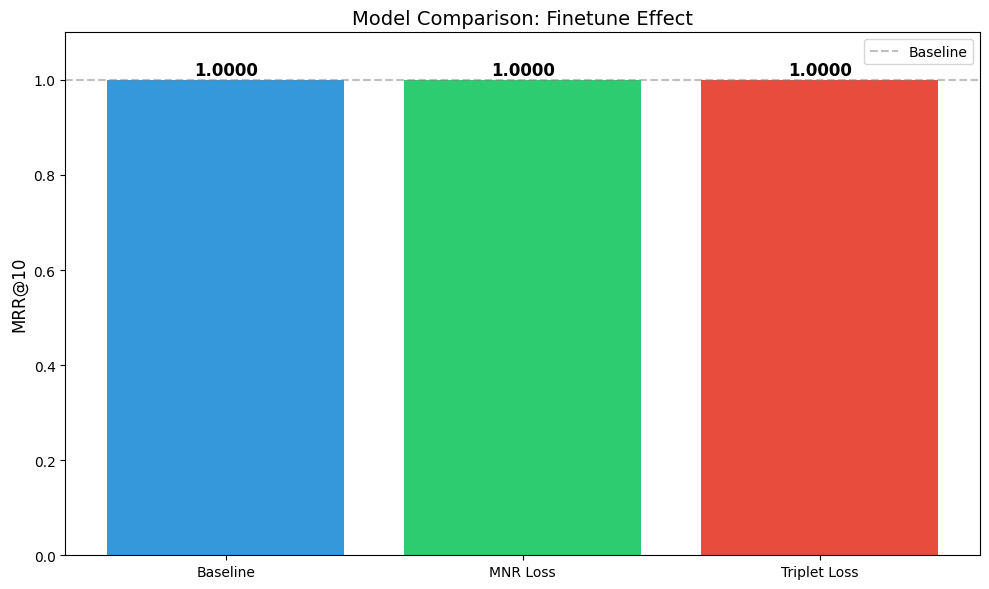

In [23]:
# 視覺化比較
models = list(results.keys())

# 1️⃣ 指定我們要畫的指標
target_metric = 'dev_cosine_mrr@10'

# 2️⃣ 用串列生成式 (List Comprehension)，把每個模型的 MRR 分數從字典中獨立抽出來
scores = [eval_dict[target_metric] for eval_dict in results.values()]

plt.figure(figsize=(10, 6))
# 避免模型數量少於顏色數量時報錯，加上[:len(models)]確保長度一致
colors = ['#3498db', '#2ecc71', '#e74c3c'][:len(models)] 
bars = plt.bar(models, scores, color=colors)

# 加上數值標籤
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 0.01,
        f'{score:.4f}',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.ylabel('MRR@10', fontsize=12)
plt.title('Model Comparison: Finetune Effect', fontsize=14)
plt.ylim(0, 1.1)

# 3️⃣ 基準線的高度也必須是抽出來的「數字」
baseline_score = results['Baseline'][target_metric]
plt.axhline(y=baseline_score, color='gray', linestyle='--', alpha=0.5, label='Baseline')

# 把圖例顯示出來 (因為上面有設定 label='Baseline')
plt.legend() 
plt.tight_layout()
plt.show()

In [22]:
# 定性評估：查看具體檢索結果

def show_retrieval_results(
    query: str,
    corpus: List[str],
    models: Dict[str, SentenceTransformer],
    top_k: int = 3
):
    """顯示不同模型的檢索結果"""
    print(f"Query: '{query}'")
    print("=" * 70)
    
    for model_name, model in models.items():
        q_emb = model.encode(query)
        c_embs = model.encode(corpus)
        sims = cosine_similarity([q_emb], c_embs)[0]
        
        top_indices = np.argsort(sims)[::-1][:top_k]
        
        print(f"\n{model_name}:")
        for rank, idx in enumerate(top_indices, 1):
            print(f"  {rank}. [{sims[idx]:.3f}] {corpus[idx][:70]}...")

# 測試查詢
test_queries = [
    "I forgot my password",
    "Can I get my money back?",
    "How to use discount",
]

comparison_models = {
    'Baseline': model_baseline,
    'MNR Finetuned': model_mnr_best,
}

for query in test_queries:
    show_retrieval_results(query, corpus, comparison_models)
    print("\n" + "-" * 70 + "\n")

Query: 'I forgot my password'

Baseline:
  1. [0.724] To reset your password, go to the login page and click 'Forgot Passwor...
  2. [0.427] Click 'Sign Up' on our homepage. Enter your email, create a password, ...
  3. [0.385] You can reach customer support via email at support@example.com, phone...

MNR Finetuned:
  1. [0.721] To reset your password, go to the login page and click 'Forgot Passwor...
  2. [0.414] Click 'Sign Up' on our homepage. Enter your email, create a password, ...
  3. [0.353] You can reach customer support via email at support@example.com, phone...

----------------------------------------------------------------------

Query: 'Can I get my money back?'

Baseline:
  1. [0.448] Refunds are processed within 5-7 business days after we receive your r...
  2. [0.355] If your package is lost, contact us with your order number. We'll inve...
  3. [0.350] You can reach customer support via email at support@example.com, phone...

MNR Finetuned:
  1. [0.501] Refunds are p

---
## 💾 Part 8: 儲存與載入模型

In [24]:
# 儲存最佳模型
FINAL_MODEL_PATH = './finetuned_model/best'

# 選擇效能最好的模型儲存
best_model_name = max(results, key=results.get)
print(f"🏆 最佳模型: {best_model_name}")

if best_model_name == 'MNR Loss':
    best_model = model_mnr_best
elif best_model_name == 'Triplet Loss':
    best_model = model_triplet_best
else:
    best_model = model_baseline

# 儲存
best_model.save(FINAL_MODEL_PATH)
print(f"✅ 模型已儲存至: {FINAL_MODEL_PATH}")

TypeError: '>' not supported between instances of 'dict' and 'dict'

In [25]:
# 載入模型
loaded_model = SentenceTransformer(FINAL_MODEL_PATH)

# 測試載入的模型
test_query = "How do I reset my password?"
embedding = loaded_model.encode(test_query)

print(f"✅ 模型載入成功！")
print(f"   Embedding 維度: {embedding.shape}")

FileNotFoundError: Path ./finetuned_model/best not found

---
## 🏋️ 練習: 在你自己的資料上 Finetune

嘗試使用你自己的領域資料進行 finetune。

In [ ]:
# TODO: 使用你自己的資料進行 finetune

# 1. 準備你的資料
my_data = [
    ("你的問題 1", "對應的答案 1"),
    ("你的問題 2", "對應的答案 2"),
    # 加入更多...
]

# 2. 建立 InputExamples
my_examples = create_pair_examples(my_data)

# 3. 訓練
# my_model = SentenceTransformer('all-MiniLM-L6-v2')
# my_dataloader = DataLoader(my_examples, shuffle=True, batch_size=4)
# my_loss = losses.MultipleNegativesRankingLoss(my_model)
# my_model.fit(...)

print("📝 請修改上面的程式碼，使用你自己的資料進行訓練！")

In [27]:
# 1. 準備你的法律領域資料 (台灣法律範例)
my_data = [
    ("什麼是民法上的限制行為能力人？", 
     "依據民法規定，滿七歲以上之未成年人，有限制行為能力。未成年人已結婚者，則取得完全之行為能力。"),
    
    ("公司解僱員工，需要提前多久預告？", 
     "依勞動基準法規定，繼續工作三個月以上一年未滿者，於十日前預告；一年以上三年未滿者，於二十日前預告；三年以上者，於三十日前預告。"),
    
    ("著作權的存續期間是多久？", 
     "著作財產權，除本法另有規定外，存續於著作人之生存期間及其死亡後五十年。"),
    
    ("被人罵了，什麼情況下可以請求精神賠償？", 
     "不法侵害他人之身體、健康、名譽、自由、信用、隱私、貞操，或不法侵害其他人格法益而情節重大者，被害人雖非財產上之損害，亦得請求賠償相當之金額。"),
    
    ("遇到網路詐騙該如何處理與報案？", 
     "發現疑似詐騙事件，應立即撥打165反詐騙諮詢專線查證，並得向當地警察機關報案，提供相關通聯紀錄與匯款證明以利警方偵辦。")
]

# 2. 建立 InputExamples
my_examples = create_pair_examples(my_data)

# 3. 訓練準備
print("🚀 開始微調法律領域模型...")
my_model = SentenceTransformer('all-MiniLM-L6-v2') 
my_dataloader = DataLoader(my_examples, shuffle=True, batch_size=5)
my_loss = losses.MultipleNegativesRankingLoss(my_model)

# 4. 開始訓練 (已修正)
my_model.fit(
    train_objectives=[(my_dataloader, my_loss)],
    epochs=5,                 
    warmup_steps=0,
    show_progress_bar=True
)

print("✅ 法律模型微調完成！")

# 5. 測試一下微調後的模型
test_query = "員工被開除可以要求提前通知嗎？"
print(f"\n🔍 測試問題: {test_query}")

query_emb = my_model.encode(test_query)
corpus_embs = my_model.encode([ans for _, ans in my_data]) 

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

sims = cosine_similarity([query_emb], corpus_embs)[0]
best_match_idx = np.argmax(sims)

print(f"💡 檢索到的法條 (相似度 {sims[best_match_idx]:.4f}):")
print(f"   {my_data[best_match_idx][1]}")

🚀 開始微調法律領域模型...


Step,Training Loss


✅ 法律模型微調完成！

🔍 測試問題: 員工被開除可以要求提前通知嗎？
💡 檢索到的法條 (相似度 0.6251):
   依勞動基準法規定，繼續工作三個月以上一年未滿者，於十日前預告；一年以上三年未滿者，於二十日前預告；三年以上者，於三十日前預告。


In [29]:
import os
import torch
import numpy as np
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# ⚙️ 1. 訓練參數設定 (Configuration)
# ==========================================
MODEL_NAME = 'shibing624/text2vec-base-chinese'  # 基礎模型 (若要處理純中文，實務上建議改用 'shibing624/text2vec-base-chinese')
OUTPUT_PATH = './my_legal_finetuned_model' # 模型儲存路徑
BATCH_SIZE = 16                   # 批次大小 (取決於你的 VRAM 與資料量。MNR Loss 建議越大越好，如 16, 32, 64)
EPOCHS = 10                       # 訓練回合數
WARMUP_RATIO = 0.1               # Warmup 比例 (讓學習率在初期緩慢上升，避免震盪)

print(f"🚀 啟動一條龍微調腳本！")
print(f"💻 使用硬體: {'cuda' if torch.cuda.is_available() else 'cpu'}")

# ==========================================
# 📊 2. 資料準備 (Data Preparation)
# ==========================================
# 這裡繼續使用我們剛剛的台灣法律問答作為範例
train_data = [
    ("什麼是民法上的限制行為能力人？", "依據民法規定，滿七歲以上之未成年人，有限制行為能力。未成年人已結婚者，則取得完全之行為能力。"),
    ("公司解僱員工，需要提前多久預告？", "依勞動基準法規定，繼續工作三個月以上一年未滿者，於十日前預告；一年以上三年未滿者，於二十日前預告；三年以上者，於三十日前預告。"),
    ("著作權的存續期間是多久？", "著作財產權，除本法另有規定外，存續於著作人之生存期間及其死亡後五十年。"),
    ("被人罵了，什麼情況下可以請求精神賠償？", "不法侵害他人之身體、健康、名譽、自由、信用、隱私、貞操，或不法侵害其他人格法益而情節重大者，被害人雖非財產上之損害，亦得請求賠償相當之金額。"),
    ("遇到網路詐騙該如何處理與報案？", "發現疑似詐騙事件，應立即撥打165反詐騙諮詢專線查證，並得向當地警察機關報案，提供相關通聯紀錄與匯款證明以利警方偵辦。")
]

# 將資料轉換為 Sentence Transformers 專用的 InputExample 格式 (Query, Positive 結構)
train_examples = [InputExample(texts=[q, a]) for q, a in train_data]

# 建立 DataLoader 負責批次餵資料給模型
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=BATCH_SIZE)

# ==========================================
# 🧠 3. 模型與損失函數設定 (Model & Loss)
# ==========================================
print(f"\n📦 載入基礎模型: {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME)

# 宣告使用 MultipleNegativesRankingLoss (檢索任務的神兵利器)
train_loss = losses.MultipleNegativesRankingLoss(model)

# 計算總訓練步數與 Warmup 步數
num_training_steps = len(train_dataloader) * EPOCHS
warmup_steps = int(num_training_steps * WARMUP_RATIO)

# ==========================================
# 🏋️ 4. 開始微調 (Fine-tuning)
# ==========================================
print(f"\n🔥 開始訓練... (總步數: {num_training_steps}, Warmup步數: {warmup_steps})")
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=EPOCHS,
    warmup_steps=warmup_steps,
    output_path=OUTPUT_PATH,  # 訓練完會自動存到這個資料夾
    show_progress_bar=True
)
print(f"\n✅ 模型微調完成！已儲存至: {OUTPUT_PATH}")

# ==========================================
# 🔍 5. 驗證與測試 (Testing)
# ==========================================
test_query = "員工被開除可以要求提前通知嗎？"
print(f"\n==========================================")
print(f"🔍 測試問題: {test_query}")

# 重新載入剛存好的模型，確保儲存機制正常運作
loaded_model = SentenceTransformer(OUTPUT_PATH)

# 將問題與所有答案轉成向量
query_emb = loaded_model.encode(test_query)
corpus = [ans for _, ans in train_data]
corpus_embs = loaded_model.encode(corpus)

# 計算 Cosine Similarity 並找出最高分
sims = cosine_similarity([query_emb], corpus_embs)[0]
best_match_idx = np.argmax(sims)

print(f"💡 檢索到的最吻合答案 (相似度 {sims[best_match_idx]:.4f}):")
print(f"   {corpus[best_match_idx]}")
print(f"==========================================")

🚀 啟動一條龍微調腳本！
💻 使用硬體: cuda

📦 載入基礎模型: shibing624/text2vec-base-chinese...

🔥 開始訓練... (總步數: 10, Warmup步數: 1)


Step,Training Loss



✅ 模型微調完成！已儲存至: ./my_legal_finetuned_model

🔍 測試問題: 員工被開除可以要求提前通知嗎？
💡 檢索到的最吻合答案 (相似度 0.5513):
   依勞動基準法規定，繼續工作三個月以上一年未滿者，於十日前預告；一年以上三年未滿者，於二十日前預告；三年以上者，於三十日前預告。


📦 正在載入模型...
🔍 開始評估 Base Model...
🔍 開始評估 Finetuned Model...

🏆 模型 F1-Score (Top-1) 比較
🔹 原始模型 (Base):      F1 = 0.6667 (P: 0.67, R: 0.67)
🔸 微調模型 (Finetuned): F1 = 1.0000 (P: 1.00, R: 1.00)


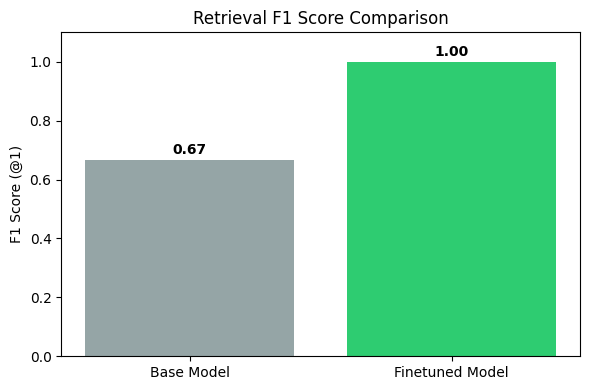

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# 1. 準備獨立的「測試集」(不要用訓練過的資料來考模型)
test_data = [
    ("勞工被資遣時，老闆要提早講嗎？", "依勞動基準法規定，繼續工作三個月以上一年未滿者，於十日前預告；一年以上三年未滿者，於二十日前預告；三年以上者，於三十日前預告。"),
    ("未成年人自己簽的合約算數嗎？", "依據民法規定，滿七歲以上之未成年人，有限制行為能力。未成年人已結婚者，則取得完全之行為能力。"),
    ("被人公然侮辱可以要求賠錢嗎？", "不法侵害他人之身體、健康、名譽、自由、信用、隱私、貞操，或不法侵害其他人格法益而情節重大者，被害人雖非財產上之損害，亦得請求賠償相當之金額。")
]

# 我們把所有看過的答案當成「法條資料庫 (Corpus)」
corpus = [
    "依據民法規定，滿七歲以上之未成年人，有限制行為能力。未成年人已結婚者，則取得完全之行為能力。",
    "依勞動基準法規定，繼續工作三個月以上一年未滿者，於十日前預告；一年以上三年未滿者，於二十日前預告；三年以上者，於三十日前預告。",
    "著作財產權，除本法另有規定外，存續於著作人之生存期間及其死亡後五十年。",
    "不法侵害他人之身體、健康、名譽、自由、信用、隱私、貞操，或不法侵害其他人格法益而情節重大者，被害人雖非財產上之損害，亦得請求賠償相當之金額。",
    "發現疑似詐騙事件，應立即撥打165反詐騙諮詢專線查證，並得向當地警察機關報案，提供相關通聯紀錄與匯款證明以利警方偵辦。"
]

# 2. 載入兩個模型
print("📦 正在載入模型...")
base_model = SentenceTransformer('all-MiniLM-L6-v2')
finetuned_model = SentenceTransformer('./my_legal_finetuned_model') # 替換成你剛剛儲存的路徑

# 3. 定義評估函數 (計算 Precision, Recall, F1)
def evaluate_retrieval(model, queries, corpus, top_k=1):
    true_positives = 0
    total_retrieved = 0
    total_relevant = len(queries) # 每個問題只有1個標準答案
    
    corpus_embs = model.encode(corpus)
    
    for query, ground_truth in queries:
        query_emb = model.encode(query)
        sims = cosine_similarity([query_emb], corpus_embs)[0]
        
        # 找出前 K 高分的文件索引
        top_indices = np.argsort(sims)[::-1][:top_k]
        retrieved_docs = [corpus[i] for i in top_indices]
        
        # 檢查標準答案是否在檢索出的文件中
        if ground_truth in retrieved_docs:
            true_positives += 1
            
        total_retrieved += top_k
        
    precision = true_positives / total_retrieved
    recall = true_positives / total_relevant
    
    # 計算 F1 Score: 2 * (P * R) / (P + R)
    if precision + recall == 0:
        f1_score = 0.0
    else:
        f1_score = 2 * (precision * recall) / (precision + recall)
        
    return precision, recall, f1_score

# 4. 執行評估
print("🔍 開始評估 Base Model...")
base_p1, base_r1, base_f1_1 = evaluate_retrieval(base_model, test_data, corpus, top_k=1)

print("🔍 開始評估 Finetuned Model...")
ft_p1, ft_r1, ft_f1_1 = evaluate_retrieval(finetuned_model, test_data, corpus, top_k=1)

# 5. 印出結果並視覺化
print("\n" + "="*40)
print("🏆 模型 F1-Score (Top-1) 比較")
print("="*40)
print(f"🔹 原始模型 (Base):      F1 = {base_f1_1:.4f} (P: {base_p1:.2f}, R: {base_r1:.2f})")
print(f"🔸 微調模型 (Finetuned): F1 = {ft_f1_1:.4f} (P: {ft_p1:.2f}, R: {ft_r1:.2f})")

# 畫圖
models = ['Base Model', 'Finetuned Model']
f1_scores = [base_f1_1, ft_f1_1]

plt.figure(figsize=(6, 4))
bars = plt.bar(models, f1_scores, color=['#95a5a6', '#2ecc71'])
plt.ylim(0, 1.1)
plt.ylabel('F1 Score (@1)')
plt.title('Retrieval F1 Score Comparison')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [36]:
!pip install --quiet ragas datasets

In [39]:
import os
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import context_precision, context_recall

# 🔑 1. 設定你的 OpenAI API Key (必須填寫真實金鑰！)
#os.environ["OPENAI_API_KEY"] = "sk-填入你真實的OpenAI金鑰"

# 2. 準備 RAGAS 嚴格規定的資料格式 (字典結構)
# 注意：ground_truths 和 contexts 裡面都必須用 list 包起來 []
data_dict = {
    "question": [
        "勞工被資遣時，老闆要提早講嗎？",
        "未成年人自己簽的合約算數嗎？"
    ],
    "ground_truths": [
        ["依勞動基準法規定，繼續工作三個月以上一年未滿者，於十日前預告；一年以上三年未滿者，於二十日前預告；三年以上者，於三十日前預告。"],
        ["依據民法規定，滿七歲以上之未成年人，有限制行為能力。未成年人已結婚者，則取得完全之行為能力。"]
    ],
    "contexts": [
        # 這是模擬你的模型檢索出來的前兩名法條 (Top-2)
        [
            "依勞動基準法規定，繼續工作三個月以上一年未滿者，於十日前預告；一年以上三年未滿者，於二十日前預告；三年以上者，於三十日前預告。",
            "不法侵害他人之身體、健康、名譽、自由、信用、隱私、貞操，或不法侵害其他人格法益而情節重大者，被害人雖非財產上之損害，亦得請求賠償相當之金額。"
        ],
        [
            "依據民法規定，滿七歲以上之未成年人，有限制行為能力。未成年人已結婚者，則取得完全之行為能力。",
            "著作財產權，除本法另有規定外，存續於著作人之生存期間及其死亡後五十年。"
        ]
    ]
}

# 3. 將字典轉換為 Hugging Face Dataset 物件
dataset = Dataset.from_dict(data_dict)
print("✅ Dataset 準備完成！長這樣：")
print(dataset)

# 4. 執行 RAGAS 評估
print("\n🚀 呼叫 LLM 進行 RAGAS 評分中 (這會花一點時間與 API 費用)...")
try:
    result = evaluate(
        dataset,
        metrics=[context_precision, context_recall]
    )
    print("\n📊 RAGAS 評估結果：")
    print(result)
except Exception as e:
    print(f"\n❌ 發生錯誤，通常是因為 API Key 無效或未設定：\n{e}")

✅ Dataset 準備完成！長這樣：
Dataset({
    features: ['question', 'ground_truths', 'contexts'],
    num_rows: 2
})

🚀 呼叫 LLM 進行 RAGAS 評分中 (這會花一點時間與 API 費用)...

❌ 發生錯誤，通常是因為 API Key 無效或未設定：
The metric [context_precision] that is used requires the following additional columns ['reference'] to be present in the dataset.


In [10]:
import os
import torch
from datasets import load_dataset
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# ==========================================
# ⚙️ 1. 訓練參數設定 (OOM 防護版)
# ==========================================
MODEL_NAME = 'shibing624/text2vec-base-chinese'
OUTPUT_PATH = './public_domain_finetuned_model_v2' # 換個新名字，避免跟剛剛爛掉的模型混淆

BATCH_SIZE = 16                  # 先用 16 確保不會爆 VRAM (若 VRAM 已清空可開到 32/64)
EPOCHS = 3                       
WARMUP_RATIO = 0.1
MAX_SAMPLES = 10000              

print(f"🚀 啟動修正版資料微調腳本！")
if torch.cuda.is_available():
    print(f"💻 偵測到神卡: {torch.cuda.get_device_name(0)} (VRAM 準備就緒)")

# ==========================================
# 📊 2. 下載與「精準」萃取資料
# ==========================================
DATASET_NAME = "Heng666/Taiwan-patent-qa" 
print(f"\n📦 正在從 Hugging Face 下載資料集 ({DATASET_NAME})...")
try:
    dataset = load_dataset(DATASET_NAME, split="train")
except Exception as e:
    dataset = load_dataset(DATASET_NAME)['train']

train_examples = []
count = 0

# 🔥 關鍵修正：針對 Instruction Tuning 資料集，精準抓取真實問答
for row in dataset:
    # 優先抓取 'input' (這才是使用者真正的問題)
    query = str(row.get('input', '')).strip()
    
    # 如果 input 是空的，退而求其次抓 instruction 或 question
    if not query:
        query = str(row.get('instruction', row.get('question', ''))).strip()
        
    # 答案通常在 'output' 或 'answer'
    answer = str(row.get('output', row.get('answer', ''))).strip()
    
    # 確保兩者都有內容，才加入訓練集
    if query and answer: 
        train_examples.append(InputExample(texts=[query, answer]))
        count += 1
        
    if MAX_SAMPLES and count >= MAX_SAMPLES:
        break

print(f"✅ 成功萃取 {len(train_examples)} 筆「真實」的訓練雙元組 (Pairs)！")
print(f"👀 [檢查第一筆資料]\n   問: {train_examples[0].texts[0][:50]}...\n   答: {train_examples[0].texts[1][:50]}...")

# 建立 DataLoader
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=BATCH_SIZE)

# ==========================================
# 🧠 3. 模型與損失函數設定
# ==========================================
print(f"\n📦 載入中文基礎模型: {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME)

train_loss = losses.MultipleNegativesRankingLoss(model)
num_training_steps = len(train_dataloader) * EPOCHS
warmup_steps = int(num_training_steps * WARMUP_RATIO)

# ==========================================
# 🏋️ 4. 開始微調 (Fine-tuning)
# ==========================================
print(f"\n🔥 開始火力全開訓練... (Batch Size: {BATCH_SIZE}, 總步數: {num_training_steps})")
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=EPOCHS,
    warmup_steps=warmup_steps,
    output_path=OUTPUT_PATH,
    show_progress_bar=True
)
print(f"\n✅ 模型微調完成！已儲存至: {OUTPUT_PATH}")

# ==========================================
# 🔍 5. 實戰測試
# ==========================================
test_query = "請問專利權的期限是多久？"
print(f"\n🔍 測試問題: {test_query}")

query_emb = model.encode(test_query)

# 從資料集中隨機抽 1000 筆答案當作搜索庫來驗證
sample_corpus = [ex.texts[1] for ex in train_examples[:1000]]
corpus_embs = model.encode(sample_corpus)

sims = cosine_similarity([query_emb], corpus_embs)[0]
best_match_idx = np.argmax(sims)

print(f"💡 檢索到的最相關文本 (相似度 {sims[best_match_idx]:.4f}):")
print(f"   {sample_corpus[best_match_idx][:150]}...")

🚀 啟動修正版資料微調腳本！
💻 偵測到神卡: NVIDIA GeForce RTX 4070 Ti SUPER (VRAM 準備就緒)

📦 正在從 Hugging Face 下載資料集 (Heng666/Taiwan-patent-qa)...
✅ 成功萃取 1215 筆「真實」的訓練雙元組 (Pairs)！
👀 [檢查第一筆資料]
   問: 支援利用專利審查高速公路審查作業方案(TW-SUPA)與我國跟其他國家簽訂之專利審查高速公路(PPH...
   答: 為提升我國與PPH簽訂國之間專利審查結果分享，本局自101年3月1日起啟動「支援利用專利審查高速公路...

📦 載入中文基礎模型: shibing624/text2vec-base-chinese...

🔥 開始火力全開訓練... (Batch Size: 16, 總步數: 228)


Step,Training Loss



✅ 模型微調完成！已儲存至: ./public_domain_finetuned_model_v2

🔍 測試問題: 請問專利權的期限是多久？
💡 檢索到的最相關文本 (相似度 0.6409):
   專利權存續期間一旦屆滿，即屬公共財，任何人就可以加以利用，原則上不可以延長，但醫藥品、農藥品或其製造方法發明專利權之實施，應取得許可證者，在未取得許可之前並無法上市，但專利權期間卻一直在消耗，為補償專利權人，專利法第53條規定此類專利，專利權人得申請延長專利權期間至多5年，並以一次為限。...


📦 正在載入基礎模型與微調模型...

📦 正在載入測試資料 (Heng666/Taiwan-patent-qa)...
✅ 成功準備 100 個測試問題，文獻庫大小: 984

🔍 評估 [原始模型 Base Model] 中...
   [1/2] 向量化 984 篇文獻庫中...
   [2/2] 開始進行檢索測試...

🔍 評估 [微調模型 Finetuned Model] 中...
   [1/2] 向量化 984 篇文獻庫中...
   [2/2] 開始進行檢索測試...

🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟
   🏆 模型終極評估成績單 (Top-5)
🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟
【指標說明】
 - Recall@5 (召回率): 前 5 名有抓到正確答案的機率
 - MRR@5 (排名忠誠度): 正確答案排得越前面，分數越接近 1
 - F1@1: 嚴格看第 1 名的綜合準確率
--------------------------------------------------
🔹 原始模型 (Base):
   Recall@5: 0.6500 | MRR@5 (忠誠度): 0.5142 | F1@1: 0.4400
🔸 微調模型 (Finetuned):
   Recall@5: 1.0000 | MRR@5 (忠誠度): 0.8557 | F1@1: 0.7500


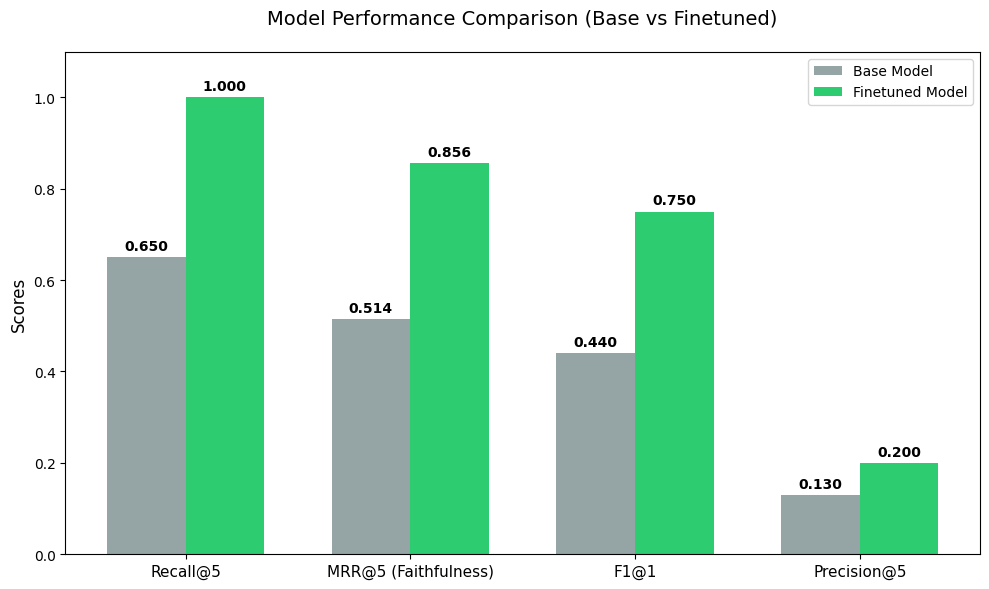

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. 載入模型 (原始 vs 微調)
# ==========================================
print("📦 正在載入基礎模型與微調模型...")
base_model_name = 'shibing624/text2vec-base-chinese'
finetuned_model_path = './public_domain_finetuned_model_v2' # 確保路徑是你剛剛訓練的 v2

base_model = SentenceTransformer(base_model_name)
finetuned_model = SentenceTransformer(finetuned_model_path)

# ==========================================
# 2. 準備測試資料 (使用真實問答)
# ==========================================
DATASET_NAME = "Heng666/Taiwan-patent-qa" 
print(f"\n📦 正在載入測試資料 ({DATASET_NAME})...")
try:
    dataset = load_dataset(DATASET_NAME, split="train")
except:
    dataset = load_dataset(DATASET_NAME)['train']

total_len = len(dataset)
test_size = 100    # 抽 100 題來考
corpus_size = 1000 # 從 1000 篇文獻中找

test_data = []
corpus = []

# 建立檢索庫 (Corpus)
for i in range(total_len - corpus_size, total_len):
    ans = str(dataset[i].get('output', dataset[i].get('answer', ''))).strip()
    if ans and ans not in corpus:
        corpus.append(ans)

# 建立測試題 (Test Queries)
for i in range(total_len - test_size, total_len):
    row = dataset[i]
    q = str(row.get('input', '')).strip()
    if not q: q = str(row.get('instruction', row.get('question', ''))).strip()
    a = str(row.get('output', row.get('answer', ''))).strip()
    if q and a: test_data.append((q, a))

print(f"✅ 成功準備 {len(test_data)} 個測試問題，文獻庫大小: {len(corpus)}")

# ==========================================
# 3. 終極評估函數 (計算 Precision, Recall, F1, MRR)
# ==========================================
def evaluate_all_metrics(model, queries, corpus, top_k=5):
    total_queries = len(queries)
    
    # 記錄用的變數
    hits_at_1 = 0
    hits_at_k = 0
    mrr_score = 0.0
    
    print(f"   [1/2] 向量化 {len(corpus)} 篇文獻庫中...")
    corpus_embs = model.encode(corpus, batch_size=32, show_progress_bar=False)
    
    print("   [2/2] 開始進行檢索測試...")
    for query, ground_truth in queries:
        query_emb = model.encode(query, show_progress_bar=False)
        sims = cosine_similarity([query_emb], corpus_embs)[0]
        
        # 抓出前 K 名
        top_indices = np.argsort(sims)[::-1][:top_k]
        retrieved_docs = [corpus[idx] for idx in top_indices]
        
        # 評估邏輯
        if ground_truth in retrieved_docs:
            hits_at_k += 1
            # 找出正確答案在第幾名 (0-indexed, 所以 +1)
            rank = retrieved_docs.index(ground_truth) + 1
            mrr_score += (1.0 / rank)
            
            if rank == 1:
                hits_at_1 += 1
                
    # 統計結果
    # 1. Recall@K (召回率): 有多少比例的問題，能在前 K 名找到答案？
    recall_k = hits_at_k / total_queries
    
    # 2. Precision@K (精確率): 撈出來的 K 篇裡面，有多少比例是正確的？
    # (因為每題只有1個標準答案，Top-5的精確率最高也只能是 1/5 = 0.2)
    precision_k = hits_at_k / (total_queries * top_k)
    
    # 3. Recall@1 / Precision@1 (Top-1 的情況下兩者相等)
    recall_1 = hits_at_1 / total_queries
    
    # 4. F1-Score@1 (基於 Top-1 計算的 F1 分數)
    f1_1 = 0.0 if (recall_1 + recall_1) == 0 else 2 * (recall_1 * recall_1) / (recall_1 + recall_1)
    
    # 5. MRR@K (排名忠誠度)
    mrr_k = mrr_score / total_queries
    
    return {
        "Recall@5": recall_k,
        "Precision@5": precision_k,
        "F1@1": f1_1,
        "MRR@5": mrr_k
    }

# ==========================================
# 4. 執行評估
# ==========================================
print("\n🔍 評估 [原始模型 Base Model] 中...")
base_metrics = evaluate_all_metrics(base_model, test_data, corpus, top_k=5)

print("\n🔍 評估 [微調模型 Finetuned Model] 中...")
ft_metrics = evaluate_all_metrics(finetuned_model, test_data, corpus, top_k=5)

# ==========================================
# 5. 輸出結果與視覺化比較
# ==========================================
print("\n" + "🌟"*25)
print("   🏆 模型終極評估成績單 (Top-5)")
print("🌟"*25)
print(f"【指標說明】")
print(f" - Recall@5 (召回率): 前 5 名有抓到正確答案的機率")
print(f" - MRR@5 (排名忠誠度): 正確答案排得越前面，分數越接近 1")
print(f" - F1@1: 嚴格看第 1 名的綜合準確率")
print("-" * 50)
print(f"🔹 原始模型 (Base):")
print(f"   Recall@5: {base_metrics['Recall@5']:.4f} | MRR@5 (忠誠度): {base_metrics['MRR@5']:.4f} | F1@1: {base_metrics['F1@1']:.4f}")
print(f"🔸 微調模型 (Finetuned):")
print(f"   Recall@5: {ft_metrics['Recall@5']:.4f} | MRR@5 (忠誠度): {ft_metrics['MRR@5']:.4f} | F1@1: {ft_metrics['F1@1']:.4f}")

# 畫圖比較
labels = ['Recall@5', 'MRR@5 (Faithfulness)', 'F1@1', 'Precision@5']
base_vals = [base_metrics['Recall@5'], base_metrics['MRR@5'], base_metrics['F1@1'], base_metrics['Precision@5']]
ft_vals = [ft_metrics['Recall@5'], ft_metrics['MRR@5'], ft_metrics['F1@1'], ft_metrics['Precision@5']]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, base_vals, width, label='Base Model', color='#95a5a6')
rects2 = ax.bar(x + width/2, ft_vals, width, label='Finetuned Model', color='#2ecc71')

ax.set_ylabel('Scores', fontsize=12)
ax.set_title('Model Performance Comparison (Base vs Finetuned)', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend()

# 標上數字
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

In [11]:
import os
import torch
import random
from datasets import load_dataset
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses

# ==========================================
# ⚙️ 1. 設定獨立路徑
# ==========================================
MODEL_NAME = 'shibing624/text2vec-base-chinese'
TRIPLET_OUTPUT_PATH = './model_triplet_final' # 💡 獨立路徑

BATCH_SIZE = 16 
EPOCHS = 3
MAX_SAMPLES = 5000 

print(f"🚀 啟動 Triplet 重新訓練程序...")

# 2. 準備資料
dataset = load_dataset("Heng666/Taiwan-patent-qa", split="train")

all_data = []
for row in dataset:
    q = str(row.get('input', '')).strip()
    a = str(row.get('output', '')).strip()
    if q and a: all_data.append((q, a))

# 3. 建構三元組
train_examples = []
all_answers = [d[1] for d in all_data]
limit = min(MAX_SAMPLES, len(all_data))

for i in range(limit):
    anchor, positive = all_data[i]
    # 隨機抽一個負樣本
    neg_idx = random.randint(0, len(all_answers)-1)
    while neg_idx == i: neg_idx = random.randint(0, len(all_answers)-1)
    negative = all_answers[neg_idx]
    
    train_examples.append(InputExample(texts=[anchor, positive, negative]))

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=BATCH_SIZE)

# 4. 訓練
model = SentenceTransformer(MODEL_NAME)
# triplet_margin 設為 5，強迫正負樣本拉開距離
train_loss = losses.TripletLoss(model=model, triplet_margin=5)

print(f"🔥 正在訓練 Triplet 模型至: {TRIPLET_OUTPUT_PATH}")
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=EPOCHS,
    show_progress_bar=True,
    output_path=TRIPLET_OUTPUT_PATH
)
print("✅ Triplet 訓練完成！")

🚀 啟動 Triplet 重新訓練程序...
🔥 正在訓練 Triplet 模型至: ./model_triplet_final


Step,Training Loss


✅ Triplet 訓練完成！


🔍 正在載入並評估: ./public_domain_finetuned_model_v2...
🔍 正在載入並評估: ./model_triplet_final...

🏆 終極成績單 (含 Precision)：
                Recall@1  Recall@5  Precision@5  MRR@5  NDCG@5
MNRL (Pair-v2)       0.0       0.0          0.0    0.0     0.0
Triplet (三元組)        0.0       0.0          0.0    0.0     0.0


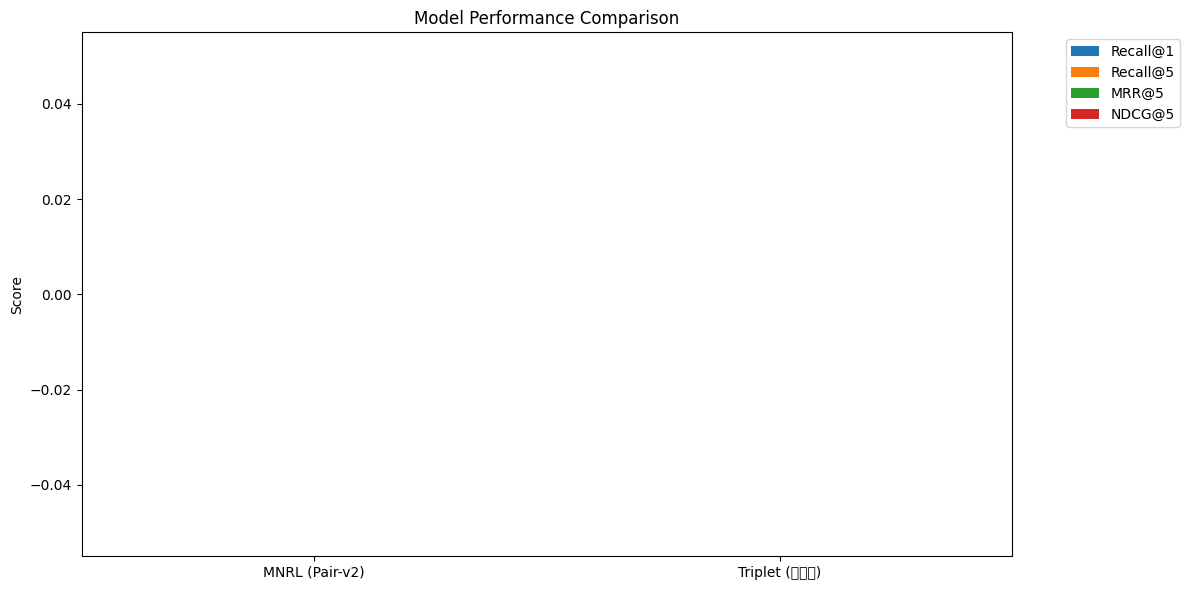

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import os

# ==========================================
# 1. 配置模型路徑 (修正讀取邏輯)
# ==========================================
MODELS_TO_TEST = {
    "Base (原始)": "shibing624/text2vec-base-chinese",
    "MNRL (Pair-v2)": "./public_domain_finetuned_model_v2",
    "Triplet (三元組)": "./model_triplet_final"
}

# 2. 準備測試資料 (使用剛才定義好的 all_data)
test_size = 100
corpus_size = 1000
test_queries = all_data[-test_size:] # 取最後100筆
test_corpus = [d[1] for d in all_data[-corpus_size:]] # 取最後1000個答案

def run_eval(model_name_or_path):
    print(f"🔍 正在載入並評估: {model_name_or_path}...")
    m = SentenceTransformer(model_name_or_path)
    c_embs = m.encode(test_corpus, batch_size=32, show_progress_bar=False)
    
    res = {
        "Recall@1": 0, 
        "Recall@5": 0, 
        "Precision@5": 0, # 新增精確率
        "MRR@5": 0, 
        "NDCG@5": 0
    }
    
    for q, gold in test_queries:
        q_emb = m.encode(q, show_progress_bar=False)
        sims = cosine_similarity([query_emb], c_embs)[0]
        top_idx = np.argsort(sims)[::-1][:5]
        top_docs = [test_corpus[i] for i in top_idx]
        
        if gold in top_docs:
            rank = top_docs.index(gold) + 1
            # Recall & Precision 邏輯
            res["Recall@5"] += 1
            res["Precision@5"] += (1 / 5) # 撈 5 篇中只有 1 篇對
            
            if rank == 1:
                res["Recall@1"] += 1
            
            # MRR (排名忠誠度)
            res["MRR@5"] += (1.0 / rank)
            # NDCG
            res["NDCG@5"] += (1.0 / np.log2(rank + 1))
                
    for k in res: res[k] /= len(test_queries)
    return res

# 3. 執行大 PK
final_report = {}
for name, path in MODELS_TO_TEST.items():
    # 修正：如果是 HuggingFace 模型或路徑存在才跑
    if not os.path.sep in path or os.path.exists(path):
        final_report[name] = run_eval(path)

# 4. 展現成果
df = pd.DataFrame(final_report).T
print("\n🏆 終極成績單 (含 Precision)：")
print(df.round(4))

# 繪圖
df.drop(columns=['Precision@5']).plot(kind='bar', figsize=(12, 6), rot=0)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

📦 正在載入資料集進行評估預備...
🔍 正在評估模型: shibing624/text2vec-base-chinese...
🔍 正在評估模型: ./public_domain_finetuned_model_v2...
🔍 正在評估模型: ./model_triplet_final...

🏆 專利法律檢索模型：三方大對決 (Base vs Pair vs Triplet)
                 Recall@1  Recall@5  Precision@5   MRR@5  NDCG@5
Base (Original)      0.44      0.64        0.128  0.5117  0.5434
MNRL (Pair-v2)       0.75      0.99        0.198  0.8537  0.8884
Triplet (Final)      0.37      0.57        0.114  0.4373  0.4702


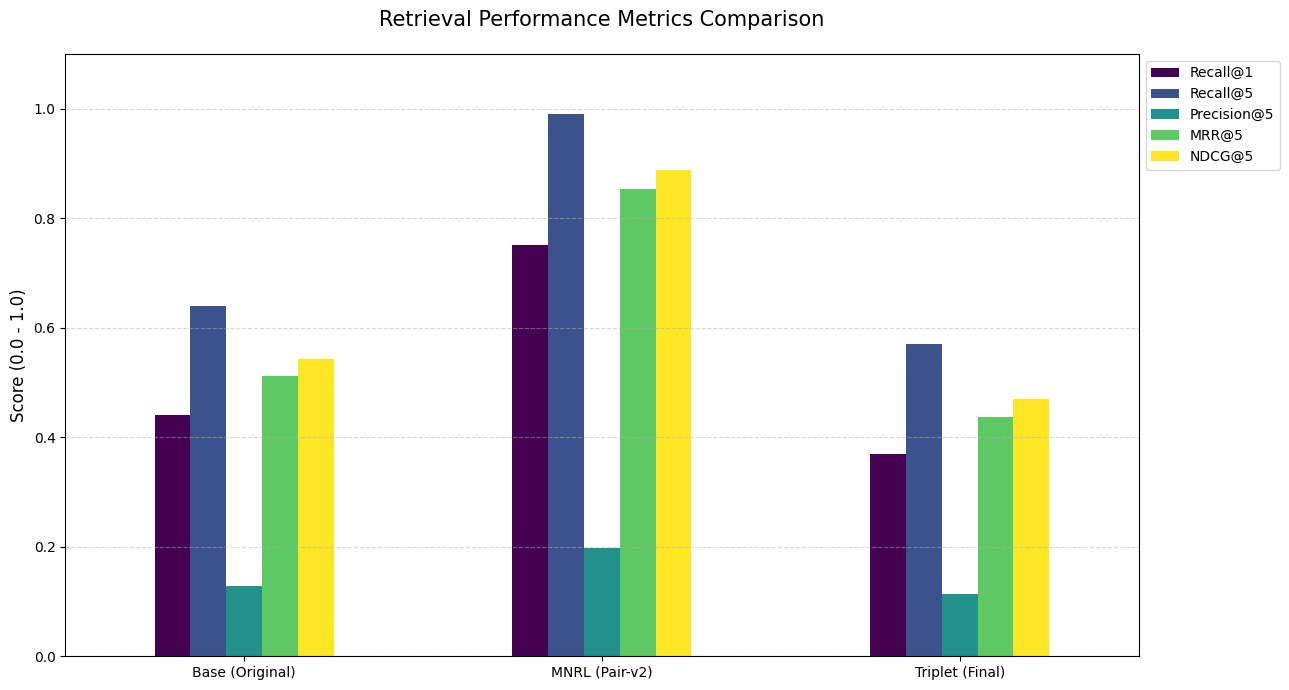

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from datasets import load_dataset

# ==========================================
# 1. 準備評估資料 (確保與訓練集分離)
# ==========================================
print("📦 正在載入資料集進行評估預備...")
dataset = load_dataset("Heng666/Taiwan-patent-qa", split="train")

all_data = []
for row in dataset:
    q = str(row.get('input', '')).strip()
    if not q: q = str(row.get('instruction', row.get('question', ''))).strip()
    a = str(row.get('output', '')).strip()
    if q and a: all_data.append((q, a))

# 測試集 100 題，檢索庫 1000 筆
test_size = 100
corpus_size = 1000
test_queries = all_data[-test_size:]
test_corpus = [d[1] for d in all_data[-corpus_size:]]

# ==========================================
# 2. 定義模型路徑 (修正 Base Model 載入邏輯)
# ==========================================
MODELS_TO_COMPARE = {
    "Base (Original)": "shibing624/text2vec-base-chinese", # 從網路抓取
    "MNRL (Pair-v2)": "./public_domain_finetuned_model_v2",  # 你訓練的 Pair
    "Triplet (Final)": "./model_triplet_final"               # 你訓練的 Triplet
}

# ==========================================
# 3. 核心評估函數
# ==========================================
def evaluate_retrieval(model_path):
    print(f"🔍 正在評估模型: {model_path}...")
    try:
        # 如果是本地路徑但不存在，跳過
        if "./" in model_path and not os.path.exists(model_path):
            print(f"⚠️ 找不到本地路徑: {model_path}")
            return None
        model = SentenceTransformer(model_path)
    except Exception as e:
        print(f"❌ 載入失敗: {e}")
        return None
        
    corpus_embs = model.encode(test_corpus, batch_size=32, show_progress_bar=False)
    metrics = {"Recall@1": 0, "Recall@5": 0, "Precision@5": 0, "MRR@5": 0, "NDCG@5": 0}
    
    for query, gold_answer in test_queries:
        query_emb = model.encode(query, show_progress_bar=False)
        similarities = cosine_similarity([query_emb], corpus_embs)[0]
        
        top_k_indices = np.argsort(similarities)[::-1][:5]
        retrieved_docs = [test_corpus[i] for i in top_k_indices]
        
        if gold_answer in retrieved_docs:
            rank = retrieved_docs.index(gold_answer) + 1
            metrics["Recall@5"] += 1
            metrics["Precision@5"] += (1 / 5)
            metrics["MRR@5"] += (1.0 / rank)
            metrics["NDCG@5"] += (1.0 / np.log2(rank + 1))
            if rank == 1: metrics["Recall@1"] += 1
                
    num_q = len(test_queries)
    for k in metrics: metrics[k] /= num_q
    return metrics

# ==========================================
# 4. 執行與繪圖
# ==========================================
results = {}
for name, path in MODELS_TO_COMPARE.items():
    res = evaluate_retrieval(path)
    if res: results[name] = res

df_report = pd.DataFrame(results).T
print("\n" + "="*65)
print("🏆 專利法律檢索模型：三方大對決 (Base vs Pair vs Triplet)")
print("="*65)
print(df_report.round(4))
print("="*65)

# 視覺化圖表
df_report.plot(kind='bar', figsize=(13, 7), rot=0, colormap='viridis')
plt.title("Retrieval Performance Metrics Comparison", fontsize=15, pad=20)
plt.ylabel("Score (0.0 - 1.0)", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
plt.tight_layout()
plt.show()

---
## 📝 總結

### 本實驗學到的重點

1. **Sentence Transformers 訓練流程**
   - 準備 InputExamples
   - 選擇適合的 Loss Function
   - 建立 Evaluator 監控訓練

2. **Loss Functions**
   - MultipleNegativesRankingLoss: 簡單高效，推薦首選
   - TripletLoss: 需要明確的三元組，可控性高

3. **Training 技巧**
   - 較大的 batch size 通常效果更好
   - Warmup 幫助穩定訓練初期
   - 使用 evaluator 監控避免 overfitting

4. **效能評估**
   - 使用 IR Evaluator 量化效能
   - 比較 finetune 前後的改進

### 下一步
在 Lab 05 中，我們將探索 Sparse Representations 和 Seismic！

---
## 📚 參考資源

- [Sentence Transformers Training](https://www.sbert.net/docs/training/overview.html)
- [Loss Functions 詳解](https://www.sbert.net/docs/package_reference/losses.html)
- [Training Examples](https://github.com/UKPLab/sentence-transformers/tree/master/examples/training)
- [Hugging Face Model Hub](https://huggingface.co/models?library=sentence-transformers)